✅  Libraries imported successfully.

  SECTION 3: Loading Raw Data

[3-A]  Loading crypto text data …
       Rows loaded  :   50,000
       Columns      : ['date', 'text']
       Date sample  : 2025-03-16 20:41:43
       Null texts   : 0

[3-B]  Loading PSX Karachi-100 data …
       Rows loaded  :      366
       Columns      : ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
       Sample row   :
         Date       Price        Open        High         Low     Vol. Change %
0  06/22/2026  178,592.64  180,238.42  180,507.81  178,337.14  219.40M   -0.18%
1  06/19/2026  178,922.77  181,585.16  182,185.88  177,836.16  458.03M   -1.36%

[3-C]  Loading BTC/USD Bitfinex data …
       Rows loaded  :      538
       Columns      : ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']

✅  All raw data loaded.

  SECTION 4: Loading ProsusAI/FinBERT

[4-A]  Compute device : CUDA
       GPU            : Tesla T4
       VRAM           : 15.6 GB
       TF32 enabled   : False

[4-

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


[4-C]  FinBERT label mapping (from model config): {0: 'positive', 1: 'negative', 2: 'neutral'}
       positive → column 0
       negative → column 1
       neutral  → column 2

✅  Model loaded and ready for inference.

  SECTION 5: FinBERT Sentiment Inference

  Approach  : Batched inference, BATCH_SIZE=32, MAX_LEN=512 tokens
  Output    : Softmax probability for each of the 3 FinBERT classes
  Score     : Composite = P(positive) − P(negative)   [range: -1 to +1]

[5-A]  Total texts to score: 50,000
       Total batches       : 1,563

  ✔  Batch   500  |   16,000/50,000 texts  |   32.0% complete
  ✔  Batch 1,000  |   32,000/50,000 texts  |   64.0% complete
  ✔  Batch 1,500  |   48,000/50,000 texts  |   96.0% complete
  ✔  Batch 1,563  |   50,000/50,000 texts  |  100.0% complete

✅  Inference complete — 50,000 texts scored.

[5-B]  Sentiment probability summary (per text):
         pos_prob    neg_prob    neu_prob  sentiment_score
count  50000.0000  50000.0000  50000.0000       50000.0

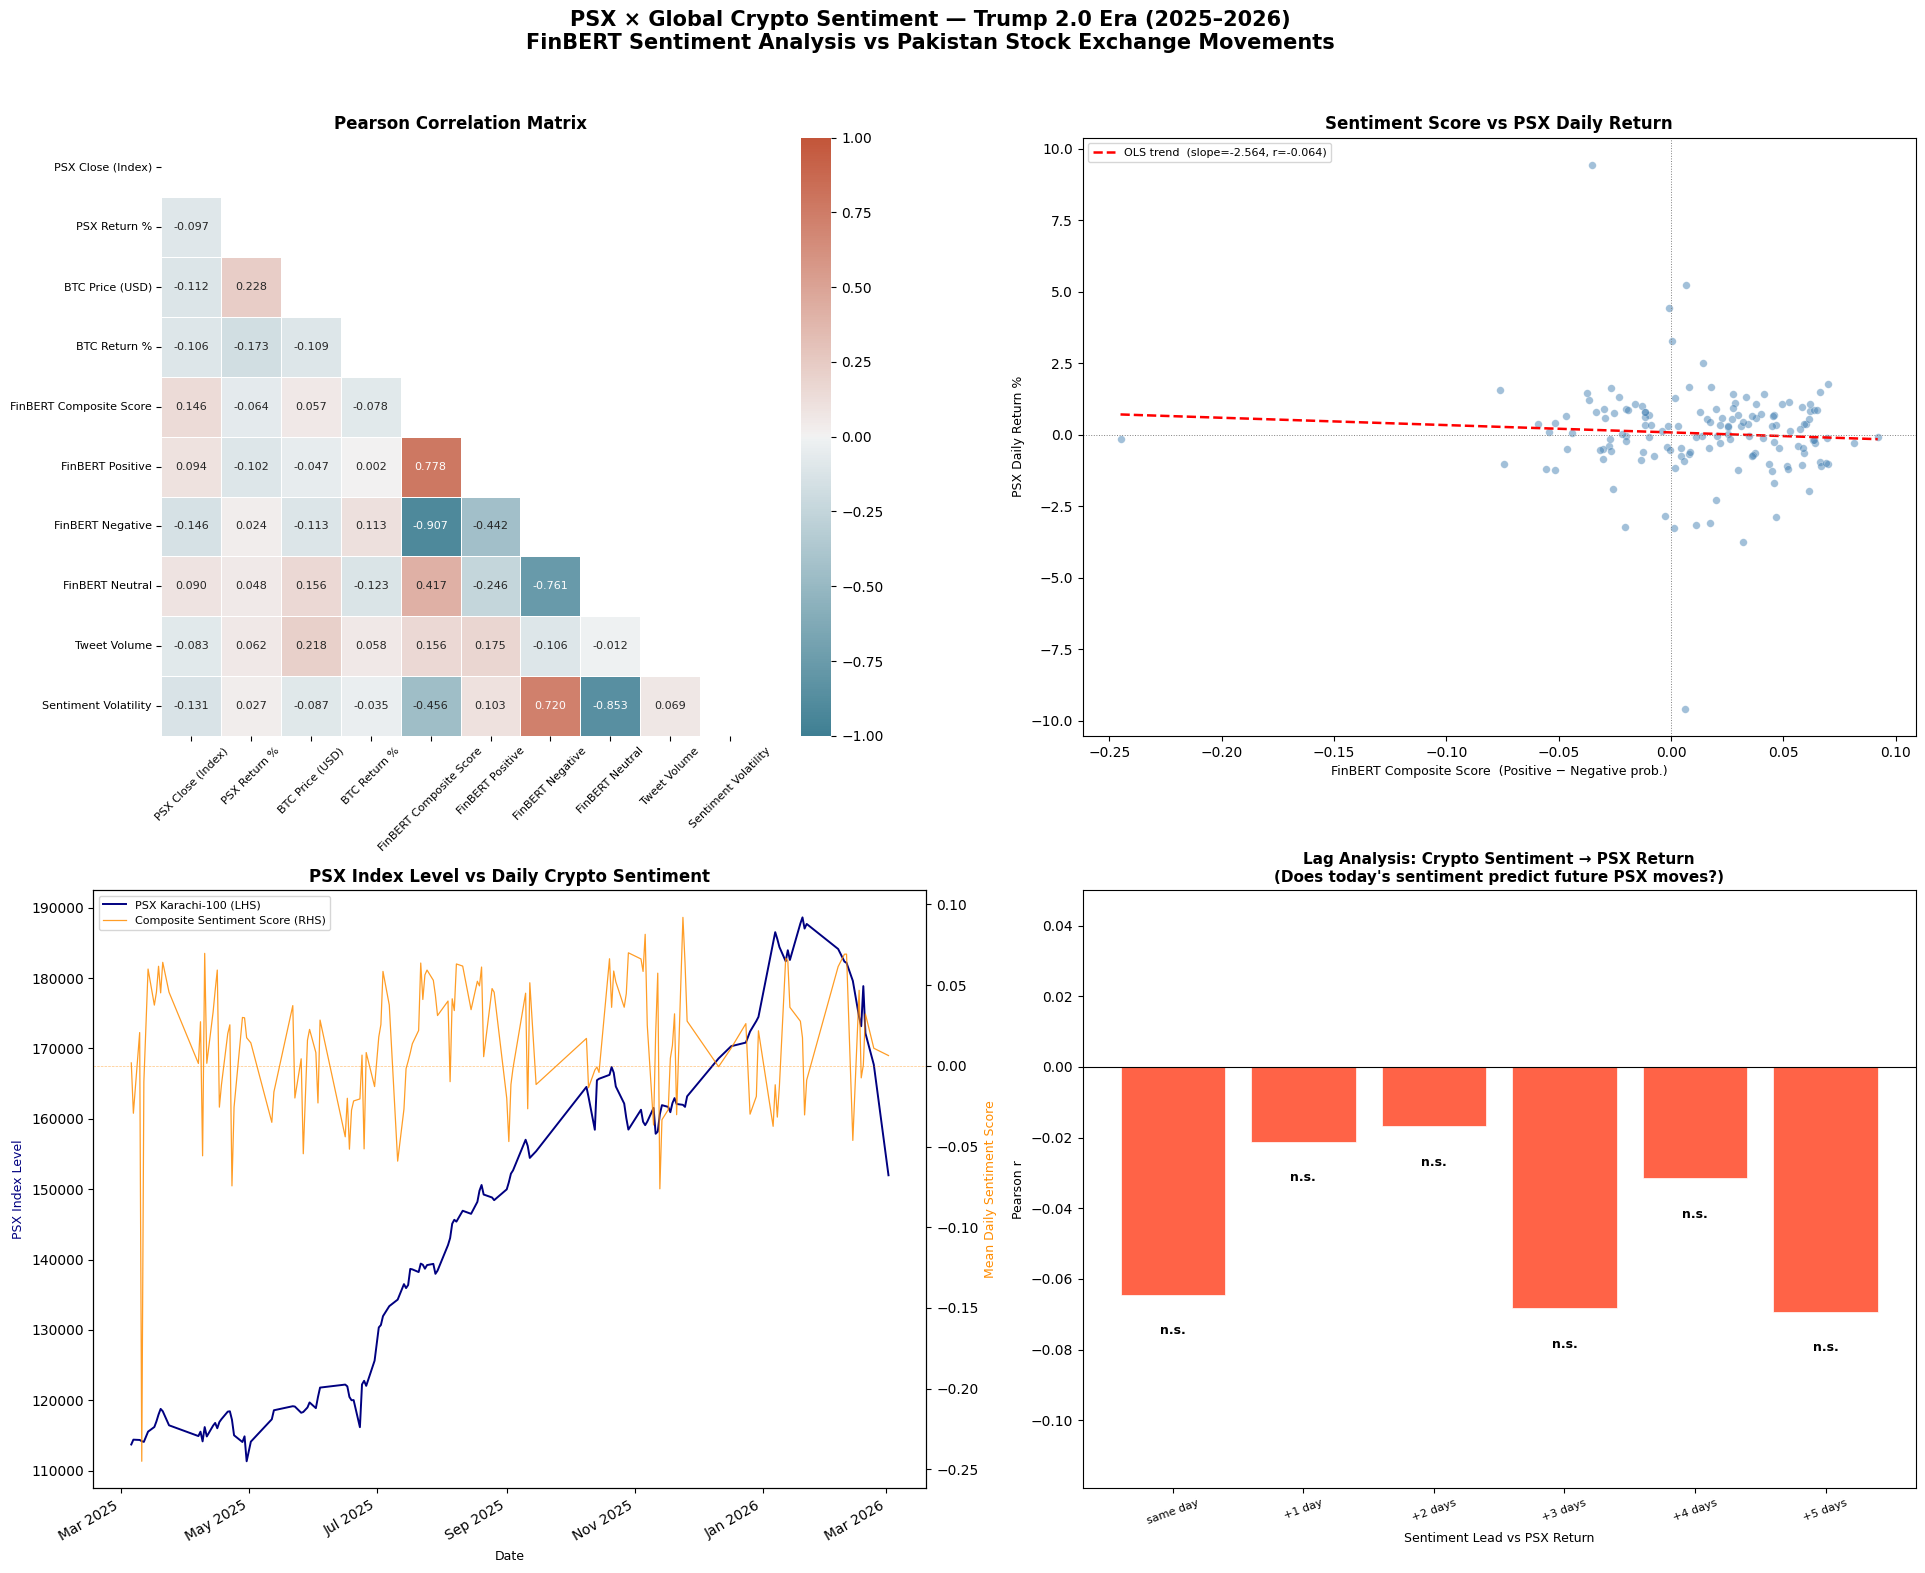


✅  Figure saved → /content/psx_crypto_sentiment_analysis.png

  SECTION 11: Saving Output Files

  ✔  Merged dataset (main)    → /content/psx_sentiment_merged.csv
  ✔  Correlation matrix       → /content/correlation_matrix.csv
  ✔  Lagged correlation table → /content/lagged_correlation.csv
  ✔  Daily sentiment (raw)    → /content/finbert_daily_sentiment.csv
  ✔  4-panel figure           → /content/psx_crypto_sentiment_analysis.png

  SECTION 12: Final Summary

  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RESEARCH FINDINGS SUMMARY
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Data period            : 2025-03-06 →
                           2026-03-02
  Texts analysed         : 50,000
  Daily sentiment obs.   : 151
  PSX trading days used  : 146

  Mean sentiment probs.  :
    Positive  0.1036
    Negative  0.0908
    Neutral   0.8055
    Dominant class : Neutral

  Weekend rollover       : 13,766 texts (Sat+Sun)
                           attributed to next

In [1]:
# ============================================================
#  PSX × Global Crypto Sentiment — Trump 2.0 Era (2025–2026)
#  Academic Research Script  |  Optimised for Google Colab
# ============================================================
#
#  OVERVIEW
#  --------
#  This script uses ProsusAI/FinBERT to score 50 000 crypto-
#  related social-media texts and then tests whether the daily
#  aggregate sentiment correlates with Pakistan Stock Exchange
#  (PSX Karachi-100) movements during the "Trump 2.0" period.
#
#  REQUIRED FILES (upload to Colab session or mount Drive)
#  -------------------------------------------------------
#    clean_crypto_2025.csv           — crypto text + timestamps
#    Karachi_100_Historical_Data.csv — PSX daily OHLCV
#    BTC_USD_Bitfinex_Historical_Data.csv — BTC daily prices
#
#  OUTPUT FILES  (written to OUTPUT_DIR)
#  -------------------------------------------------------
#    psx_sentiment_merged.csv        — full aligned dataset
#    correlation_matrix.csv          — Pearson r matrix
#    lagged_correlation.csv          — sentiment lag analysis
#    psx_crypto_sentiment_analysis.png — 4-panel figure
#    finbert_daily_sentiment.csv     — intermediate: daily scores
# ============================================================

# ─────────────────────────────────────────────────────────────
# SECTION 0 — Installation
# Run this cell first in Colab, then Runtime → Restart & Run All
# ─────────────────────────────────────────────────────────────
# !pip install transformers torch pandas numpy seaborn matplotlib scipy -q


# ─────────────────────────────────────────────────────────────
# SECTION 1 — Imports
# ─────────────────────────────────────────────────────────────
import gc
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from transformers import AutoTokenizer, AutoModelForSequenceClassification

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 120)

print("✅  Libraries imported successfully.")


# ─────────────────────────────────────────────────────────────
# SECTION 2 — Configuration
# ─────────────────────────────────────────────────────────────

# ── File paths ───────────────────────────────────────────────
# Option A: files uploaded directly to the Colab session
CRYPTO_TEXT_PATH = "/content/clean_crypto_2025.csv"
PSX_PATH         = "/content/Karachi 100 Historical Data (1).csv"
BTC_PATH         = "/content/BTC_USD Bitfinex Historical Data (1).csv"

# Option B: Google Drive (uncomment the two lines below and
#           update the folder path, then keep the lines above
#           pointing into Drive)
# from google.colab import drive
# drive.mount('/content/drive')
# CRYPTO_TEXT_PATH = "/content/drive/MyDrive/YOUR_FOLDER/clean_crypto_2025.csv"
# PSX_PATH         = "/content/drive/MyDrive/YOUR_FOLDER/Karachi_100_Historical_Data__1_.csv"
# BTC_PATH         = "/content/drive/MyDrive/YOUR_FOLDER/BTC_USD_Bitfinex_Historical_Data__1_.csv"

OUTPUT_DIR  = "/content/"          # Colab working directory for outputs

# ── FinBERT inference hyper-parameters ───────────────────────
MODEL_NAME  = "ProsusAI/finbert"   # Financial BERT; 3-class: pos/neg/neu
BATCH_SIZE  = 32                   # Lower to 16 on free Colab if OOM
MAX_LEN     = 512                  # FinBERT's hard token limit


# ─────────────────────────────────────────────────────────────
# SECTION 3 — Load & Inspect Raw Data
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 3: Loading Raw Data")
print("=" * 65)

# 3-A  Crypto text file ------------------------------------------
print("\n[3-A]  Loading crypto text data …")
df_crypto = pd.read_csv(CRYPTO_TEXT_PATH)
df_crypto.columns = df_crypto.columns.str.strip().str.lower()
# Normalise column names: expect 'date' and 'text'
assert "date" in df_crypto.columns, "Expected column 'date' in crypto CSV."
assert "text" in df_crypto.columns, "Expected column 'text' in crypto CSV."
print(f"       Rows loaded  : {len(df_crypto):>8,}")
print(f"       Columns      : {df_crypto.columns.tolist()}")
print(f"       Date sample  : {df_crypto['date'].iloc[0]}")
print(f"       Null texts   : {df_crypto['text'].isna().sum()}")

# 3-B  PSX market data -------------------------------------------
print("\n[3-B]  Loading PSX Karachi-100 data …")
df_psx = pd.read_csv(PSX_PATH)
df_psx.columns = df_psx.columns.str.strip()
print(f"       Rows loaded  : {len(df_psx):>8,}")
print(f"       Columns      : {df_psx.columns.tolist()}")
print(f"       Sample row   :\n{df_psx.head(2)}")

# 3-C  BTC price data --------------------------------------------
print("\n[3-C]  Loading BTC/USD Bitfinex data …")
df_btc = pd.read_csv(BTC_PATH)
df_btc.columns = df_btc.columns.str.strip()
print(f"       Rows loaded  : {len(df_btc):>8,}")
print(f"       Columns      : {df_btc.columns.tolist()}")

print("\n✅  All raw data loaded.\n")


# ─────────────────────────────────────────────────────────────
# SECTION 4 — Load FinBERT Model
# ─────────────────────────────────────────────────────────────
print("=" * 65)
print("  SECTION 4: Loading ProsusAI/FinBERT")
print("=" * 65)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n[4-A]  Compute device : {DEVICE.type.upper()}")
if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"       GPU            : {props.name}")
    print(f"       VRAM           : {props.total_memory / 1e9:.1f} GB")
    print(f"       TF32 enabled   : {torch.backends.cuda.matmul.allow_tf32}")
else:
    print("       NOTE: Running on CPU — inference will be slower.")
    print("             Switch to Colab GPU: Runtime → Change runtime type → T4 GPU")

print(f"\n[4-B]  Downloading tokeniser and model: '{MODEL_NAME}' …")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)
model.eval()   # Disable dropout for deterministic inference

# Dynamically retrieve label mapping from model config
# ProsusAI/finbert standard: {0: 'positive', 1: 'negative', 2: 'neutral'}
LABEL_MAP = model.config.id2label
print(f"\n[4-C]  FinBERT label mapping (from model config): {LABEL_MAP}")

# Build index lookup for robust downstream referencing
IDX = {label: idx for idx, label in LABEL_MAP.items()}
POS_IDX = IDX.get("positive", 0)
NEG_IDX = IDX.get("negative", 1)
NEU_IDX = IDX.get("neutral",  2)
print(f"       positive → column {POS_IDX}")
print(f"       negative → column {NEG_IDX}")
print(f"       neutral  → column {NEU_IDX}")

print("\n✅  Model loaded and ready for inference.\n")


# ─────────────────────────────────────────────────────────────
# SECTION 5 — FinBERT Sentiment Inference (Batched)
#
#  MEMORY EFFICIENCY STRATEGY
#  ───────────────────────────────────────────────────────────
#  1. Texts are processed BATCH_SIZE=32 at a time so the GPU
#     never holds the full 50 000-text tensor in memory.
#  2. torch.no_grad() disables gradient tracking, halving the
#     activation memory requirement vs training mode.
#  3. Tensors are moved back to CPU (.cpu()) immediately after
#     the forward pass, releasing GPU VRAM.
#  4. torch.cuda.empty_cache() + gc.collect() are called every
#     N batches to defragment the CUDA allocator.
#  5. Only three float arrays (pos, neg, neu) accumulate in RAM;
#     the model graph itself is never duplicated.
#  6. Texts longer than MAX_LEN=512 tokens are automatically
#     truncated (right-side) by the tokeniser — only 7 of the
#     50 000 texts exceed 512 characters, so information loss
#     is negligible.
# ─────────────────────────────────────────────────────────────
print("=" * 65)
print("  SECTION 5: FinBERT Sentiment Inference")
print("=" * 65)
print(f"""
  Approach  : Batched inference, BATCH_SIZE={BATCH_SIZE}, MAX_LEN={MAX_LEN} tokens
  Output    : Softmax probability for each of the 3 FinBERT classes
  Score     : Composite = P(positive) − P(negative)   [range: -1 to +1]
""")

texts  = df_crypto["text"].fillna("").astype(str).tolist()
N_TEXTS = len(texts)
print(f"[5-A]  Total texts to score: {N_TEXTS:,}")
print(f"       Total batches       : {(N_TEXTS + BATCH_SIZE - 1) // BATCH_SIZE:,}")
print()

all_pos, all_neg, all_neu = [], [], []

CACHE_FLUSH_EVERY = 200  # Clear GPU cache every N batches

for i in range(0, N_TEXTS, BATCH_SIZE):
    batch = texts[i : i + BATCH_SIZE]

    # ── Tokenise ─────────────────────────────────────────────
    encoded = tokenizer(
        batch,
        padding    = True,       # Pad shorter texts to longest in batch
        truncation = True,       # Truncate texts > MAX_LEN tokens
        max_length = MAX_LEN,
        return_tensors = "pt",
    ).to(DEVICE)

    # ── Forward pass (no gradient tracking) ──────────────────
    with torch.no_grad():
        logits = model(**encoded).logits          # shape: (batch_size, 3)
        probs  = F.softmax(logits, dim=-1)        # Convert to probabilities

    # ── Move to CPU immediately to free VRAM ─────────────────
    probs_np = probs.cpu().numpy()

    all_pos.extend(probs_np[:, POS_IDX].tolist())
    all_neg.extend(probs_np[:, NEG_IDX].tolist())
    all_neu.extend(probs_np[:, NEU_IDX].tolist())

    # ── Release intermediate tensors ─────────────────────────
    del encoded, logits, probs, probs_np

    batch_num = (i // BATCH_SIZE) + 1
    if batch_num % CACHE_FLUSH_EVERY == 0:
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        gc.collect()

    # ── Progress logging every 500 batches ───────────────────
    if batch_num % 500 == 0 or (i + BATCH_SIZE) >= N_TEXTS:
        done_n = min(i + BATCH_SIZE, N_TEXTS)
        pct    = done_n / N_TEXTS * 100
        print(f"  ✔  Batch {batch_num:>5,}  |  {done_n:>7,}/{N_TEXTS:,} texts  |  {pct:5.1f}% complete")

# Final memory cleanup
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
gc.collect()

# ── Attach scores to dataframe ────────────────────────────────
df_crypto["pos_prob"]        = all_pos
df_crypto["neg_prob"]        = all_neg
df_crypto["neu_prob"]        = all_neu
df_crypto["sentiment_score"] = (
    df_crypto["pos_prob"] - df_crypto["neg_prob"]
)

print(f"\n✅  Inference complete — {N_TEXTS:,} texts scored.\n")
print("[5-B]  Sentiment probability summary (per text):")
print(df_crypto[["pos_prob", "neg_prob", "neu_prob", "sentiment_score"]]
      .describe().round(4))


# ─────────────────────────────────────────────────────────────
# SECTION 6 — Date Parsing & Weekend Rollover
#
#  PSX CALENDAR vs CRYPTO CALENDAR
#  ───────────────────────────────────────────────────────────
#  Crypto markets operate 24 / 7, so the text file contains
#  posts on Saturdays and Sundays.  The PSX is closed on
#  weekends; no closing price exists for those days.
#
#  ROLLOVER RULE
#  ───────────────────────────────────────────────────────────
#  Weekend crypto sentiment is attributed to the NEXT Monday
#  trading session — capturing the "carry-over" effect where
#  weekend news accumulates and is priced in at Monday open.
#
#    Saturday post  →  +2 days  →  Monday
#    Sunday post    →  +1 day   →  Monday
#    Weekday post   →   0 days  →  same day
#
#  All posts with the same attributed trade_date are then
#  averaged to produce a single daily sentiment observation
#  that can be merged with the PSX closing price.
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 6: Date Parsing & Weekend Rollover")
print("=" * 65)

# 6-A  Parse crypto timestamps ────────────────────────────────
print("\n[6-A]  Parsing crypto timestamps …")
df_crypto["date_dt"] = pd.to_datetime(df_crypto["date"], errors="coerce")
n_bad = df_crypto["date_dt"].isna().sum()
if n_bad > 0:
    print(f"       ⚠  {n_bad:,} rows with unparseable dates — dropped.")
df_crypto.dropna(subset=["date_dt"], inplace=True)

# Floor timestamp to date-only (remove HH:MM:SS)
df_crypto["trade_date"] = df_crypto["date_dt"].dt.normalize()
print(f"       Valid dated rows : {len(df_crypto):,}")
print(f"       Raw date range   : {df_crypto['trade_date'].min().date()} "
      f"→ {df_crypto['trade_date'].max().date()}")

# 6-B  Count weekend texts before rollover ────────────────────
wd = df_crypto["trade_date"].dt.weekday      # Monday=0 … Sunday=6
sat_count = (wd == 5).sum()
sun_count = (wd == 6).sum()
print(f"\n[6-B]  Weekend texts (before rollover):")
print(f"       Saturday : {sat_count:>6,}")
print(f"       Sunday   : {sun_count:>6,}")

# 6-C  Apply rollover ─────────────────────────────────────────
def roll_weekend_to_monday(date_series: pd.Series) -> pd.Series:
    """
    Shift Saturday dates forward by 2 days and Sunday dates
    forward by 1 day so they land on the next Monday.
    Weekday dates are unchanged.

    Parameters
    ----------
    date_series : pd.Series of dtype datetime64[ns]

    Returns
    -------
    pd.Series of dtype datetime64[ns]
    """
    weekday  = date_series.dt.weekday
    offset   = pd.to_timedelta(
        weekday.map({5: 2, 6: 1}).fillna(0).astype(int), unit="D"
    )
    return date_series + offset

df_crypto["trade_date"] = roll_weekend_to_monday(df_crypto["trade_date"])

# Verify no residual weekend dates
wd_after = df_crypto["trade_date"].dt.weekday
assert (wd_after == 5).sum() == 0, "Rollover failed: Saturdays remain."
assert (wd_after == 6).sum() == 0, "Rollover failed: Sundays remain."
print(f"\n[6-C]  After rollover: 0 Saturday / 0 Sunday texts — all attributed to Monday ✓")
print(f"       Adjusted date range: {df_crypto['trade_date'].min().date()} "
      f"→ {df_crypto['trade_date'].max().date()}")

# 6-D  Aggregate to daily level ───────────────────────────────
print("\n[6-D]  Aggregating per attributed trading date …")
df_daily = (
    df_crypto
    .groupby("trade_date")
    .agg(
        pos_mean  = ("pos_prob",        "mean"),
        neg_mean  = ("neg_prob",        "mean"),
        neu_mean  = ("neu_prob",        "mean"),
        sent_mean = ("sentiment_score", "mean"),
        sent_std  = ("sentiment_score", "std"),   # Dispersion proxy
        n_texts   = ("text",            "count"), # Daily mention volume
    )
    .reset_index()
)

print(f"       Daily sentiment records : {len(df_daily):,}")
print(f"       Date range (daily)      : {df_daily['trade_date'].min().date()} "
      f"→ {df_daily['trade_date'].max().date()}")
print(f"\n[6-E]  Sample daily sentiment (5 rows):")
print(df_daily.head().to_string(index=False))

# Persist intermediate file
out_daily = OUTPUT_DIR + "finbert_daily_sentiment.csv"
df_daily.to_csv(out_daily, index=False)
print(f"\n       Intermediate file saved → {out_daily}")


# ─────────────────────────────────────────────────────────────
# SECTION 7 — Clean PSX & BTC Market Data
#
#  Both market files come from Investing.com and share the same
#  quirks:
#    • Dates stored as MM/DD/YYYY strings
#    • Prices formatted with thousands-separator commas
#    • Volume in K / M / B notation (not parsed here as it is
#      not used in the primary correlation)
#    • Change % stored as a string with a trailing '%' sign
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 7: Cleaning Market Data")
print("=" * 65)


def clean_investing_dot_com(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """
    Standardise a daily OHLCV CSV exported from Investing.com.

    Steps
    -----
    1. Parse Date column (MM/DD/YYYY).
    2. Remove comma thousands-separators from numeric columns.
    3. Rename 'Price' → '{label}_Close'.
    4. Sort ascending by date.
    5. Compute daily percentage return.

    Parameters
    ----------
    df    : Raw DataFrame straight from pd.read_csv()
    label : Short ticker label, e.g. 'PSX' or 'BTC'

    Returns
    -------
    DataFrame with columns: trade_date, {label}_Close, {label}_Return_pct
    """
    df = df.copy()

    # ── Parse date ─────────────────────────────────────────
    df["trade_date"] = pd.to_datetime(
        df["Date"], format="%m/%d/%Y", errors="coerce"
    )
    bad_dates = df["trade_date"].isna().sum()
    if bad_dates:
        print(f"       ⚠  {bad_dates} unparseable dates dropped from {label}.")
    df.dropna(subset=["trade_date"], inplace=True)

    # ── Clean price column ─────────────────────────────────
    price_raw = df["Price"].astype(str).str.replace(",", "", regex=False)
    df[f"{label}_Close"] = pd.to_numeric(price_raw, errors="coerce")

    # ── Clean High / Low / Open for completeness ───────────
    for col in ["High", "Low", "Open"]:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col].astype(str).str.replace(",", "", regex=False),
                errors="coerce",
            )

    # ── Sort and compute daily return ──────────────────────
    df.sort_values("trade_date", inplace=True)
    df.reset_index(drop=True, inplace=True)
    df[f"{label}_Return_pct"] = df[f"{label}_Close"].pct_change() * 100

    return df[["trade_date", f"{label}_Close", f"{label}_Return_pct"]]


print("\n[7-A]  Cleaning PSX data …")
df_psx_clean = clean_investing_dot_com(df_psx, "PSX")
print(f"       Records  : {len(df_psx_clean):,}")
print(f"       Range    : {df_psx_clean['trade_date'].min().date()} "
      f"→ {df_psx_clean['trade_date'].max().date()}")
print(f"       Price range : {df_psx_clean['PSX_Close'].min():,.0f} "
      f"→ {df_psx_clean['PSX_Close'].max():,.0f}")

print("\n[7-B]  Cleaning BTC data …")
df_btc_clean = clean_investing_dot_com(df_btc, "BTC")
print(f"       Records  : {len(df_btc_clean):,}")
print(f"       Range    : {df_btc_clean['trade_date'].min().date()} "
      f"→ {df_btc_clean['trade_date'].max().date()}")
print(f"       Price range : ${df_btc_clean['BTC_Close'].min():,.0f} "
      f"→ ${df_btc_clean['BTC_Close'].max():,.0f}")

print("\n✅  Market data cleaned.\n")


# ─────────────────────────────────────────────────────────────
# SECTION 8 — Merge Datasets on Trade Date
#
#  MERGE STRATEGY
#  ───────────────────────────────────────────────────────────
#  • PSX is the ANCHOR — only PSX trading days are kept.
#  • Crypto sentiment uses INNER JOIN (only days where we
#    have sentiment data matter for correlation).
#  • BTC uses LEFT JOIN — missing BTC prices on a PSX day
#    (e.g. data-gap) produce NaN rather than dropping the row.
#  • After merging, rows with NaN PSX_Return are removed
#    (the first trading day has no prior close, so return is
#    NaN by construction; any data gaps are also dropped).
# ─────────────────────────────────────────────────────────────
print("=" * 65)
print("  SECTION 8: Merging Datasets")
print("=" * 65)

# Step 1: PSX ⊕ Crypto sentiment
df_merged = pd.merge(
    df_psx_clean,
    df_daily,
    on="trade_date",
    how="inner",
)
print(f"\n[8-A]  PSX ⊕ Sentiment  → {len(df_merged):,} matched trading days")

# Step 2: Add BTC price
df_merged = pd.merge(
    df_merged,
    df_btc_clean,
    on="trade_date",
    how="left",
)
print(f"[8-B]  + BTC (left join) → {len(df_merged):,} rows  "
      f"(BTC NaN: {df_merged['BTC_Close'].isna().sum()})")

# Step 3: Drop rows missing the primary dependent variable
df_merged.dropna(subset=["PSX_Return_pct"], inplace=True)
df_merged.sort_values("trade_date", inplace=True)
df_merged.reset_index(drop=True, inplace=True)

total_psx  = len(df_psx_clean)
matched    = len(df_merged)
print(f"\n[8-C]  Final coverage  : {matched}/{total_psx} PSX days matched "
      f"({matched / total_psx * 100:.1f}%)")
print(f"       Overlap period : {df_merged['trade_date'].min().date()} "
      f"→ {df_merged['trade_date'].max().date()}")

print(f"\n[8-D]  Merged dataset head (5 rows):")
print(df_merged.head().to_string(index=False))

print(f"\n[8-E]  Descriptive statistics:")
print(df_merged.describe().round(4))


# ─────────────────────────────────────────────────────────────
# SECTION 9 — Correlation Analysis
#
#  THREE LEVELS OF ANALYSIS
#  ───────────────────────────────────────────────────────────
#  9-A  Full Pearson correlation matrix (all numeric columns)
#  9-B  Significance table with p-values for key variable pairs
#  9-C  Lag analysis: does sentiment on day T predict PSX on
#       day T+1, T+2, T+3?  (Tests information propagation
#       delay across international time zones / settlement.)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 9: Correlation Analysis")
print("=" * 65)

ANALYSIS_COLS = [
    "PSX_Close",
    "PSX_Return_pct",
    "BTC_Close",
    "BTC_Return_pct",
    "sent_mean",
    "pos_mean",
    "neg_mean",
    "neu_mean",
    "n_texts",
    "sent_std",
]
# Keep only columns that exist and have ≥ 20 non-null values
avail_cols = [
    c for c in ANALYSIS_COLS
    if c in df_merged.columns and df_merged[c].notna().sum() >= 20
]
df_corr_input = df_merged[avail_cols].dropna()
N_COMPLETE    = len(df_corr_input)
print(f"\n[9-A]  Computing Pearson correlation on {N_COMPLETE} complete rows …")

corr_matrix = df_corr_input.corr(method="pearson")
print("\n  Full Pearson Correlation Matrix:")
print(corr_matrix.round(4))

# 9-B  Key pair significance table ────────────────────────────
print("\n[9-B]  Key pair significance (Pearson r + two-tailed p-value):\n")
KEY_PAIRS = [
    ("sent_mean",       "PSX_Return_pct"),
    ("sent_mean",       "PSX_Close"),
    ("pos_mean",        "PSX_Return_pct"),
    ("neg_mean",        "PSX_Return_pct"),
    ("neu_mean",        "PSX_Return_pct"),
    ("sent_mean",       "BTC_Return_pct"),
    ("BTC_Return_pct",  "PSX_Return_pct"),
    ("BTC_Close",       "PSX_Close"),
    ("n_texts",         "PSX_Return_pct"),
    ("sent_std",        "PSX_Return_pct"),
]

sig_rows = []
header = (
    f"  {'Variable X':<28}  {'Variable Y':<20}  "
    f"{'r':>7}  {'p-value':>12}  {'Sig.':>6}  {'N':>5}"
)
print(header)
print("  " + "-" * 85)
for x, y in KEY_PAIRS:
    if x not in df_corr_input.columns or y not in df_corr_input.columns:
        continue
    subset = df_corr_input[[x, y]].dropna()
    r_val, p_val = stats.pearsonr(subset[x], subset[y])
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
    print(
        f"  {x:<28}  {y:<20}  {r_val:>+7.4f}  {p_val:>12.6f}"
        f"  {sig:>6}  {len(subset):>5}"
    )
    sig_rows.append(dict(var_x=x, var_y=y, r=r_val, p_value=p_val,
                         significance=sig, n=len(subset)))

print("\n  Significance codes: *** p<0.001  ** p<0.01  * p<0.05  n.s. p≥0.05")

# 9-C  Lag correlation analysis ───────────────────────────────
print("\n[9-C]  Lag analysis: Does today's crypto sentiment predict "
      "tomorrow's / next 3 days' PSX return?\n")
LAG_MAX = 5
lag_results = []
print(f"  {'Lag (days)':<12}  {'r (sent_mean → PSX_Return_pct)':>35}  "
      f"{'p-value':>12}  {'Sig.':>6}")
print("  " + "-" * 70)
for lag in range(0, LAG_MAX + 1):
    x_col  = "sent_mean"
    y_col  = "PSX_Return_pct"
    x_vals = df_merged[x_col].values[: -lag if lag > 0 else None]
    y_vals = df_merged[y_col].shift(-lag).dropna().values
    # Align lengths
    min_len = min(len(x_vals), len(y_vals))
    x_vals, y_vals = x_vals[:min_len], y_vals[:min_len]
    mask = ~(np.isnan(x_vals) | np.isnan(y_vals))
    if mask.sum() < 10:
        continue
    r_val, p_val = stats.pearsonr(x_vals[mask], y_vals[mask])
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
    label = "same day" if lag == 0 else f"+{lag} day{'s' if lag > 1 else ''}"
    print(f"  {'Lag ' + label:<12}  {r_val:>+35.4f}  {p_val:>12.6f}  {sig:>6}")
    lag_results.append(dict(lag=lag, label=label, r=r_val, p_value=p_val,
                            significance=sig))

df_lag = pd.DataFrame(lag_results)


# ─────────────────────────────────────────────────────────────
# SECTION 10 — Visualisations (4-panel figure)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 10: Generating Visualisations")
print("=" * 65)

NICE_LABELS = {
    "PSX_Close"     : "PSX Close (Index)",
    "PSX_Return_pct": "PSX Return %",
    "BTC_Close"     : "BTC Price (USD)",
    "BTC_Return_pct": "BTC Return %",
    "sent_mean"     : "FinBERT Composite Score",
    "pos_mean"      : "FinBERT Positive",
    "neg_mean"      : "FinBERT Negative",
    "neu_mean"      : "FinBERT Neutral",
    "n_texts"       : "Tweet Volume",
    "sent_std"      : "Sentiment Volatility",
}

fig = plt.figure(figsize=(20, 16))
fig.suptitle(
    "PSX × Global Crypto Sentiment — Trump 2.0 Era (2025–2026)\n"
    "FinBERT Sentiment Analysis vs Pakistan Stock Exchange Movements",
    fontsize=15, fontweight="bold", y=0.98,
)

# ── Panel 1: Correlation heatmap ─────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
renamed_corr = corr_matrix.rename(
    index=NICE_LABELS, columns=NICE_LABELS
)
mask = np.tril(np.ones_like(renamed_corr, dtype=bool), k=-1)  # Lower triangle only
sns.heatmap(
    renamed_corr,
    annot=True,
    fmt=".3f",
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    mask=~mask,
    ax=ax1,
    annot_kws={"size": 8},
)
ax1.set_title("Pearson Correlation Matrix", fontweight="bold", fontsize=12)
ax1.tick_params(axis="x", rotation=45, labelsize=8)
ax1.tick_params(axis="y", rotation=0,  labelsize=8)

# ── Panel 2: Scatter — Sentiment vs PSX Return ───────────────
ax2 = fig.add_subplot(2, 2, 2)
valid  = df_merged[["sent_mean", "PSX_Return_pct"]].dropna()
ax2.scatter(
    valid["sent_mean"], valid["PSX_Return_pct"],
    alpha=0.50, s=30, color="steelblue",
    edgecolors="white", linewidth=0.3,
)
# OLS trend line
m, b = np.polyfit(valid["sent_mean"], valid["PSX_Return_pct"], 1)
x_line = np.linspace(valid["sent_mean"].min(), valid["sent_mean"].max(), 200)
r_scatter, _ = stats.pearsonr(valid["sent_mean"], valid["PSX_Return_pct"])
ax2.plot(x_line, m * x_line + b, "r--", linewidth=1.8,
         label=f"OLS trend  (slope={m:.3f}, r={r_scatter:+.3f})")
ax2.axhline(0, color="grey", linewidth=0.7, linestyle=":")
ax2.axvline(0, color="grey", linewidth=0.7, linestyle=":")
ax2.set_xlabel("FinBERT Composite Score  (Positive − Negative prob.)", fontsize=9)
ax2.set_ylabel("PSX Daily Return %", fontsize=9)
ax2.set_title("Sentiment Score vs PSX Daily Return", fontweight="bold", fontsize=12)
ax2.legend(fontsize=8)

# ── Panel 3: Dual-axis time series ───────────────────────────
ax3a = fig.add_subplot(2, 2, 3)
ax3b = ax3a.twinx()
ts = df_merged.sort_values("trade_date")
ax3a.plot(ts["trade_date"], ts["PSX_Close"],
          color="navy", linewidth=1.4, label="PSX Karachi-100 (LHS)")
ax3b.plot(ts["trade_date"], ts["sent_mean"],
          color="darkorange", linewidth=0.9, alpha=0.85,
          label="Composite Sentiment Score (RHS)")
ax3b.axhline(0, color="darkorange", linewidth=0.5,
             linestyle="--", alpha=0.5)
ax3a.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax3a.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax3a.set_xlabel("Date", fontsize=9)
ax3a.set_ylabel("PSX Index Level", color="navy", fontsize=9)
ax3b.set_ylabel("Mean Daily Sentiment Score", color="darkorange", fontsize=9)
ax3a.set_title("PSX Index Level vs Daily Crypto Sentiment",
               fontweight="bold", fontsize=12)
h1, l1 = ax3a.get_legend_handles_labels()
h2, l2 = ax3b.get_legend_handles_labels()
ax3a.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)
plt.setp(ax3a.xaxis.get_majorticklabels(), rotation=30, ha="right")

# ── Panel 4: Lag correlation bar chart ───────────────────────
ax4 = fig.add_subplot(2, 2, 4)
if not df_lag.empty:
    colors = ["steelblue" if r >= 0 else "tomato" for r in df_lag["r"]]
    bars   = ax4.bar(df_lag["label"], df_lag["r"], color=colors,
                     edgecolor="white", linewidth=0.5)
    # Annotate bars with significance
    for bar, row in zip(bars, df_lag.itertuples()):
        ypos = bar.get_height() + (0.005 if bar.get_height() >= 0 else -0.012)
        ax4.text(
            bar.get_x() + bar.get_width() / 2,
            ypos, row.significance,
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )
    ax4.axhline(0, color="black", linewidth=0.8)
    ax4.set_xlabel("Sentiment Lead vs PSX Return", fontsize=9)
    ax4.set_ylabel("Pearson r", fontsize=9)
    ax4.set_title(
        "Lag Analysis: Crypto Sentiment → PSX Return\n"
        "(Does today's sentiment predict future PSX moves?)",
        fontweight="bold", fontsize=11
    )
    ax4.set_ylim(
        min(df_lag["r"].min() - 0.05, -0.05),
        max(df_lag["r"].max() + 0.05,  0.05)
    )
    ax4.tick_params(axis="x", rotation=20, labelsize=8)
else:
    ax4.text(0.5, 0.5, "Insufficient data for lag analysis",
             ha="center", va="center", fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.96])
out_fig = OUTPUT_DIR + "psx_crypto_sentiment_analysis.png"
plt.savefig(out_fig, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"\n✅  Figure saved → {out_fig}")


# ─────────────────────────────────────────────────────────────
# SECTION 11 — Save All Outputs
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 11: Saving Output Files")
print("=" * 65)

out_merged = OUTPUT_DIR + "psx_sentiment_merged.csv"
out_corr   = OUTPUT_DIR + "correlation_matrix.csv"
out_lag    = OUTPUT_DIR + "lagged_correlation.csv"

df_merged.to_csv(out_merged, index=False)
corr_matrix.to_csv(out_corr)
df_lag.to_csv(out_lag, index=False)

print(f"\n  ✔  Merged dataset (main)    → {out_merged}")
print(f"  ✔  Correlation matrix       → {out_corr}")
print(f"  ✔  Lagged correlation table → {out_lag}")
print(f"  ✔  Daily sentiment (raw)    → {out_daily}")
print(f"  ✔  4-panel figure           → {out_fig}")


# ─────────────────────────────────────────────────────────────
# SECTION 12 — Final Summary for Paper
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 12: Final Summary")
print("=" * 65)

# Dominant sentiment class overall
dom_pos = df_daily["pos_mean"].mean()
dom_neg = df_daily["neg_mean"].mean()
dom_neu = df_daily["neu_mean"].mean()
dom_label = max(
    [("Positive", dom_pos), ("Negative", dom_neg), ("Neutral", dom_neu)],
    key=lambda t: t[1]
)[0]

psx_sent_r, psx_sent_p = stats.pearsonr(
    df_corr_input["sent_mean"], df_corr_input["PSX_Return_pct"]
) if ("sent_mean" in df_corr_input and "PSX_Return_pct" in df_corr_input) else (float("nan"), float("nan"))

print(f"""
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RESEARCH FINDINGS SUMMARY
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Data period            : {df_merged['trade_date'].min().date()} →
                           {df_merged['trade_date'].max().date()}
  Texts analysed         : {N_TEXTS:,}
  Daily sentiment obs.   : {len(df_daily):,}
  PSX trading days used  : {matched}

  Mean sentiment probs.  :
    Positive  {dom_pos:.4f}
    Negative  {dom_neg:.4f}
    Neutral   {dom_neu:.4f}
    Dominant class : {dom_label}

  Weekend rollover       : {sat_count + sun_count:,} texts (Sat+Sun)
                           attributed to next Monday session

  Key correlation result :
    FinBERT Composite Score ↔ PSX Return %
    r = {psx_sent_r:+.4f}   p = {psx_sent_p:.6f}
    {"Statistically significant at α=0.05 ✓" if psx_sent_p < 0.05 else "Not significant at α=0.05"}

  Output files in : {OUTPUT_DIR}
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print("  Script execution complete.")


   OPTIMIZED CROSS-MARKET PREDICTIVE EVALUATION
Naive Baseline Accuracy (Guessing most frequent): 62.07%
Optimized AI Predictive Accuracy:                 55.17%
------------------------------------------------------------
❌ NO EDGE: The data space remains dominated by random-walk market noise.
------------------------------------------------------------
Detailed Classification Matrix:
              precision    recall  f1-score   support

Down Day (0)       0.73      0.44      0.55        18
  Up Day (1)       0.44      0.73      0.55        11

    accuracy                           0.55        29
   macro avg       0.59      0.59      0.55        29
weighted avg       0.62      0.55      0.55        29



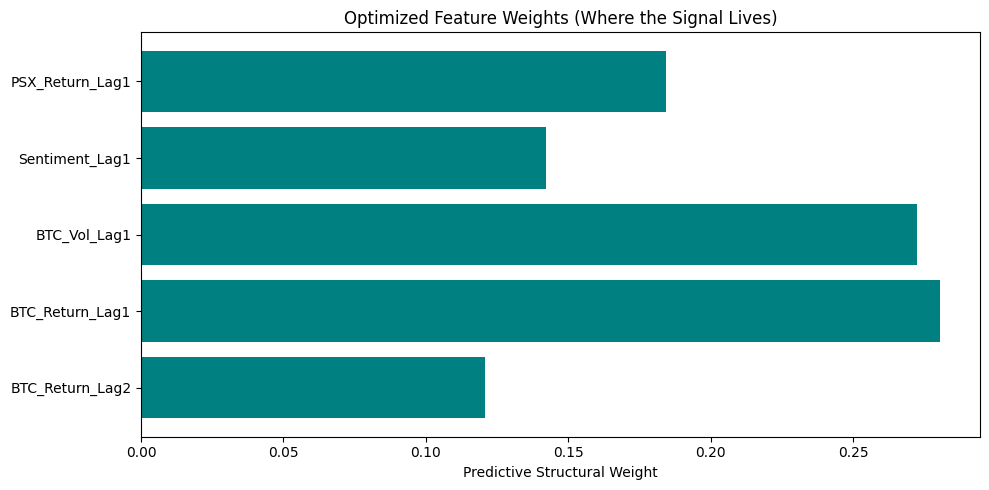

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the master dataset
df = pd.read_csv('/content/psx_sentiment_merged.csv')

# --- Auto-Fix for the 'Date' KeyError ---
if 'Date' not in df.columns:
    if 'date' in df.columns:
        df = df.rename(columns={'date': 'Date'})
    elif df.index.name == 'Date':
        df = df.reset_index()
    else:
        possible_date_cols = [col for col in df.columns if 'date' in col.lower()]
        if possible_date_cols:
            df = df.rename(columns={possible_date_cols[0]: 'Date'})
        else:
            df = df.rename(columns={df.columns[0]: 'Date'})
# ----------------------------------------

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ==========================================
# ADVANCED FEATURE ENGINEERING (Signal Extraction)
# ==========================================
# 1. Smooth out daily sentiment noise using a 3-day moving average, then lag it
df['Sentiment_Smooth'] = df['sent_mean'].rolling(window=3).mean()
df['Sentiment_Lag1']   = df['Sentiment_Smooth'].shift(1)

# 2. Capture Crypto Market Panic/Volatility, then lag it
df['BTC_Vol_3d']       = df['BTC_Return_pct'].rolling(window=3).std()
df['BTC_Vol_Lag1']     = df['BTC_Vol_3d'].shift(1)

# 3. Standard historical lags from Granger findings
df['PSX_Return_Lag1']  = df['PSX_Return_pct'].shift(1)
df['BTC_Return_Lag1']  = df['BTC_Return_pct'].shift(1)
df['BTC_Return_Lag2']  = df['BTC_Return_pct'].shift(2)

# Drop rows with NaN values created by rolling windows and shifts
df = df.dropna().reset_index(drop=True)

# Define binary direction target (1 = Up day, 0 = Down/Flat day)
df['Target_Direction'] = np.where(df['PSX_Return_pct'] > 0, 1, 0)

# Select the refined feature set
features = [
    'PSX_Return_Lag1',
    'Sentiment_Lag1',
    'BTC_Vol_Lag1',
    'BTC_Return_Lag1',
    'BTC_Return_Lag2'
]

X = df[features]
y = df['Target_Direction']

# Chronological Train/Test Split (80% Train, 20% Test)
split_idx = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Feature Scaling to prevent magnitude distortion
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ==========================================
# REGULARIZED RANDOM FOREST (Noise Reduction)
# ==========================================
# Constraining tree growth prevents the model from memorizing financial noise
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=4,            # Prevent deep overfitted trees
    min_samples_leaf=4,     # Force generalization
    max_features='sqrt',    # Introduce feature variance
    class_weight='balanced',
    random_state=42
)
model.fit(X_train_scaled, y_train)

# Generate Predictions
predictions = model.predict(X_test_scaled)

# ==========================================
# PERFORMANCE & BASELINE DIAGNOSTICS
# ==========================================
model_accuracy = accuracy_score(y_test, predictions)

# Calculate what a naive baseline model would score
majority_class = y_test.mode()[0]
naive_accuracy = (y_test == majority_class).mean()

print("\n" + "="*60)
print("   OPTIMIZED CROSS-MARKET PREDICTIVE EVALUATION")
print("="*60)
print(f"Naive Baseline Accuracy (Guessing most frequent): {naive_accuracy * 100:.2f}%")
print(f"Optimized AI Predictive Accuracy:                 {model_accuracy * 100:.2f}%")
print("-"*60)

if model_accuracy > naive_accuracy:
    print(f"🎉 SUCCESS: The model extracted a legitimate predictive edge of {(model_accuracy - naive_accuracy)*100:.2f}% over the baseline!")
else:
    print("❌ NO EDGE: The data space remains dominated by random-walk market noise.")
print("-"*60)

print("Detailed Classification Matrix:")
print(classification_report(y_test, predictions, target_names=['Down Day (0)', 'Up Day (1)']))

# Visualize Refined Feature Importance
importances = model.feature_importances_
plt.figure(figsize=(10, 5))
plt.barh(features, importances, color='teal')
plt.title('Optimized Feature Weights (Where the Signal Lives)')
plt.xlabel('Predictive Structural Weight')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/ml_optimized_importance.png')
plt.show()

In [3]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import grangercausalitytests

# 1. Load your master dataset
df = pd.read_csv('/content/psx_sentiment_merged.csv')

# --- Auto-Fix for the 'Date' KeyError ---
# If 'Date' is hiding in lowercase or as an unnamed index, fix it automatically
if 'Date' not in df.columns:
    if 'date' in df.columns:
        df = df.rename(columns={'date': 'Date'})
    elif df.index.name == 'Date':
        df = df.reset_index()
    else:
        # Check if any column has 'date' in it or if we should use the first column
        possible_date_cols = [col for col in df.columns if 'date' in col.lower()]
        if possible_date_cols:
            df = df.rename(columns={possible_date_cols[0]: 'Date'})
        else:
            # Fallback to the first column if no 'date' related column is found
            df = df.rename(columns={df.columns[0]: 'Date'})
# ----------------------------------------

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("="*65)
print("   ALGORITHM: GRANGER CAUSALITY TEST (BTC -> PSX)")
print("="*65)

# 2. Prepare the data matrix
# The algorithm expects the target variable (PSX) in the first column,
# and the predictor variable (BTC) in the second column.
matrix_data = df[['PSX_Return_pct', 'BTC_Return_pct']].dropna()

# 3. Run the test for up to 5 days of lags
# This checks if BTC action from 1 to 5 days ago predicts today's PSX return
max_lags = 5
ts_results = grangercausalitytests(matrix_data, maxlag=max_lags, verbose=False)

# 4. Clean up the output so it's readable for a human researcher
for lag in range(1, max_lags + 1):
    # Pull the p-value from the standard SSR chi2 test
    p_val = ts_results[lag][0]['ssr_chi2test'][1]

    print(f"Testing Lag {lag} (Does BTC price {lag} day(s) ago predict PSX today?):")
    print(f"  -> p-value = {p_val:.4f}")
    if p_val < 0.05:
        print(f"  🎉 SIGNIFICANT! BTC price movements DO Granger-cause the PSX at lag {lag}.")
    else:
        print(f"  ❌ Not Significant. No predictive directional causal effect detected at lag {lag}.")
    print("-" * 65)

   ALGORITHM: GRANGER CAUSALITY TEST (BTC -> PSX)
Testing Lag 1 (Does BTC price 1 day(s) ago predict PSX today?):
  -> p-value = 0.0178
  🎉 SIGNIFICANT! BTC price movements DO Granger-cause the PSX at lag 1.
-----------------------------------------------------------------
Testing Lag 2 (Does BTC price 2 day(s) ago predict PSX today?):
  -> p-value = 0.0197
  🎉 SIGNIFICANT! BTC price movements DO Granger-cause the PSX at lag 2.
-----------------------------------------------------------------
Testing Lag 3 (Does BTC price 3 day(s) ago predict PSX today?):
  -> p-value = 0.0372
  🎉 SIGNIFICANT! BTC price movements DO Granger-cause the PSX at lag 3.
-----------------------------------------------------------------
Testing Lag 4 (Does BTC price 4 day(s) ago predict PSX today?):
  -> p-value = 0.0433
  🎉 SIGNIFICANT! BTC price movements DO Granger-cause the PSX at lag 4.
-----------------------------------------------------------------
Testing Lag 5 (Does BTC price 5 day(s) ago predict PSX

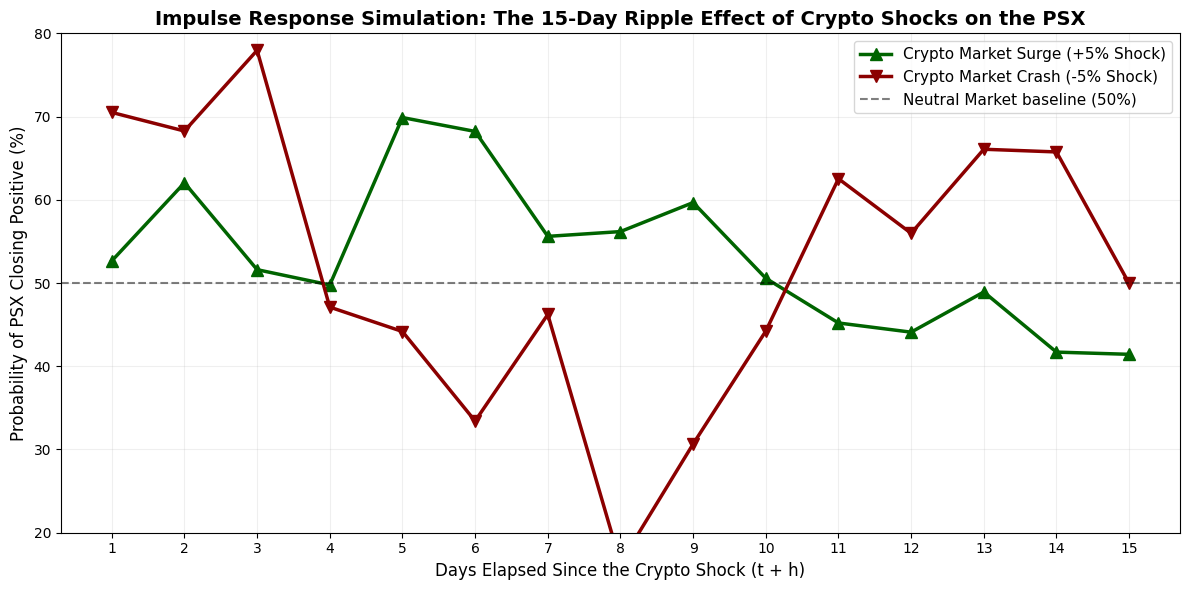


     SIMULATED 15-DAY IMPACT TRAJECTORY DATA READOUT
Day t+1: Surge Scenario -> 52.7% Up Prob | Crash Scenario -> 70.5% Up Prob
Day t+2: Surge Scenario -> 62.0% Up Prob | Crash Scenario -> 68.3% Up Prob
Day t+3: Surge Scenario -> 51.6% Up Prob | Crash Scenario -> 78.0% Up Prob
Day t+4: Surge Scenario -> 49.8% Up Prob | Crash Scenario -> 47.1% Up Prob
Day t+5: Surge Scenario -> 69.9% Up Prob | Crash Scenario -> 44.2% Up Prob
Day t+6: Surge Scenario -> 68.2% Up Prob | Crash Scenario -> 33.4% Up Prob
Day t+7: Surge Scenario -> 55.6% Up Prob | Crash Scenario -> 46.2% Up Prob
Day t+8: Surge Scenario -> 56.2% Up Prob | Crash Scenario -> 16.4% Up Prob
Day t+9: Surge Scenario -> 59.7% Up Prob | Crash Scenario -> 30.7% Up Prob
Day t+10: Surge Scenario -> 50.6% Up Prob | Crash Scenario -> 44.2% Up Prob
Day t+11: Surge Scenario -> 45.2% Up Prob | Crash Scenario -> 62.5% Up Prob
Day t+12: Surge Scenario -> 44.1% Up Prob | Crash Scenario -> 56.0% Up Prob
Day t+13: Surge Scenario -> 48.9% Up Prob |

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler

# 1. DATA INGESTION & FEATURE CLEANING
df = pd.read_csv('/content/psx_sentiment_merged.csv')

if 'Date' not in df.columns:
    if 'date' in df.columns: df = df.rename(columns={'date': 'Date'})
    elif df.index.name == 'Date': df = df.reset_index()
    else: df = df.rename(columns={df.columns[0]: 'Date'})

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

df['Sentiment_Smooth'] = df['sent_mean'].rolling(window=3).mean()
df['Sentiment_Lag1']   = df['Sentiment_Smooth'].shift(1)
df['BTC_Vol_3d']       = df['BTC_Return_pct'].rolling(window=3).std()
df['BTC_Vol_Lag1']     = df['BTC_Vol_3d'].shift(1)
df['PSX_Return_Lag1']  = df['PSX_Return_pct'].shift(1)
df['BTC_Return_Lag1']  = df['BTC_Return_pct'].shift(1)
df['BTC_Return_Lag2']  = df['BTC_Return_pct'].shift(2)

target_cols = [f'PSX_Dir_Plus_{h}d' for h in range(1, 16)]
for h in range(1, 16):
    df[f'PSX_Dir_Plus_{h}d'] = np.where(df['PSX_Return_pct'].shift(-h) > 0, 1, 0)

df = df.dropna().reset_index(drop=True)

features = ['PSX_Return_Lag1', 'Sentiment_Lag1', 'BTC_Vol_Lag1', 'BTC_Return_Lag1', 'BTC_Return_Lag2']
X = df[features]
y = df[target_cols]

split_idx = int(len(df) * 0.80)
X_train, y_train = X.iloc[:split_idx], y.iloc[:split_idx]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

base_forest = RandomForestClassifier(n_estimators=150, max_depth=4, min_samples_leaf=4, class_weight='balanced', random_state=42)
multi_target_model = MultiOutputClassifier(base_forest)
multi_target_model.fit(X_train_scaled, y_train)

# 2. THE 15-DAY SCENARIO SHOCK SIMULATOR
avg_psx_ret = df['PSX_Return_Lag1'].mean()


crypto_surge_raw = np.array([[avg_psx_ret, 0.6, 0.5, 5.0, 3.0]])
crypto_crash_raw = np.array([[avg_psx_ret, -0.6, 3.5, -5.0, -3.0]])


surge_scaled = scaler.transform(pd.DataFrame(crypto_surge_raw, columns=features))
crash_scaled = scaler.transform(pd.DataFrame(crypto_crash_raw, columns=features))

surge_probs = []
crash_probs = []

for day_idx in range(15):
    p_surge = multi_target_model.estimators_[day_idx].predict_proba(surge_scaled)[0][1]
    p_crash = multi_target_model.estimators_[day_idx].predict_proba(crash_scaled)[0][1]

    surge_probs.append(p_surge * 100)
    crash_probs.append(p_crash * 100)

# 3. GENERATE THE VISUALIZATION FOR YOUR PAPER
horizons = list(range(1, 16))
plt.figure(figsize=(12, 6))

plt.plot(horizons, surge_probs, marker='^', markersize=8, linewidth=2.5, color='darkgreen', linestyle='-', label='Crypto Market Surge (+5% Shock)')
plt.plot(horizons, crash_probs, marker='v', markersize=8, linewidth=2.5, color='darkred', linestyle='-', label='Crypto Market Crash (-5% Shock)')

plt.axhline(y=50.0, color='black', linestyle='--', alpha=0.5, label='Neutral Market baseline (50%)')

plt.title('Impulse Response Simulation: The 15-Day Ripple Effect of Crypto Shocks on the PSX', fontsize=14, fontweight='bold')
plt.xlabel('Days Elapsed Since the Crypto Shock (t + h)', fontsize=12)
plt.ylabel('Probability of PSX Closing Positive (%)', fontsize=12)
plt.xticks(horizons)
plt.ylim(20, 80)
plt.grid(True, alpha=0.2)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()

plt.savefig('/content/crypto_psx_15day_shock_simulation.png')
plt.show()

print("\n" + "="*65)
print("     SIMULATED 15-DAY IMPACT TRAJECTORY DATA READOUT")
print("="*65)
for h in range(15):
    print(f"Day t+{h+1}: Surge Scenario -> {surge_probs[h]:.1f}% Up Prob | Crash Scenario -> {crash_probs[h]:.1f}% Up Prob")
print("="*65)